# Stage 2: Baseline Modeling for AutoTuneX

This notebook implements baseline models for autoscaling prediction:
- Linear Regression
- Random Forest
- XGBoost

**Target**: Predict next-step request_rate and latency_p95

## Import required libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.multioutput import MultiOutputRegressor
import json
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully")

Libraries loaded successfully


## Load prediction-ready dataset

In [2]:
df = pd.read_csv('/kaggle/input/datasets/kiyasmahmud/autotunex-data/prediction_ready_dataset.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])
print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")
df.head()

Dataset shape: (20441, 43)
Date range: 2026-02-11 18:03:51.317955+00:00 to 2026-02-16 17:50:00.905179+00:00


,timestamp,request_rate,latency_p50,latency_p95,latency_p99,error_rate,cpu_usage,memory_usage,replica_count,cpu_per_replica,...,cpu_usage_rolling_mean_5,request_rate_rolling_std_3,latency_p95_rolling_std_3,cpu_usage_rolling_std_3,request_rate_rolling_std_5,latency_p95_rolling_std_5,cpu_usage_rolling_std_5,target_request_rate,target_latency_p95,target_replica_count
0,2026-02-11 18:03:51.317955+00:00,100.398180,0.002655,0.121457,0.224291,0.002318,19.168681,196579328.0,6.0,3.194780,...,6.004902,47.463834,0.067369,9.442214,37.232708,0.052188,7.368148,87.569790,0.146397,6.0
1,2026-02-11 18:04:01.318512+00:00,87.569790,0.002695,0.146397,0.229279,0.002982,20.633533,196608000.0,6.0,3.438922,...,9.519926,41.590934,0.075596,9.758357,42.201619,0.071292,9.496006,120.088642,0.147793,6.0
2,2026-02-11 18:04:11.318692+00:00,120.088642,0.002699,0.147793,0.229559,0.004204,20.019349,196354048.0,6.0,3.336558,...,13.091931,16.379650,0.014819,0.735601,47.626396,0.074019,9.393613,158.682463,0.162004,6.0
3,2026-02-11 18:04:21.319115+00:00,158.682463,0.002733,0.162004,0.232401,0.004728,12.177019,196354048.0,6.0,2.029503,...,15.009078,35.599557,0.008636,4.715082,49.846201,0.064126,7.502599,185.990160,0.163825,6.0
4,2026-02-11 18:04:31.319502+00:00,185.990160,0.002738,0.163825,0.232765,0.004880,19.170448,196337664.0,6.0,3.195075,...,18.233806,33.111437,0.008777,4.303697,41.021084,0.016980,3.441759,191.885641,0.167775,6.0


## Separate features and targets

In [3]:
target_cols = ['target_request_rate', 'target_latency_p95']
feature_cols = [col for col in df.columns if col not in target_cols + ['target_replica_count', 'timestamp']]

X = df[feature_cols].values
y = df[target_cols].values

print(f"Features shape: {X.shape}")
print(f"Targets shape: {y.shape}")
print(f"\nFeature columns ({len(feature_cols)}): {feature_cols[:10]}...")

Features shape: (20441, 39)
Targets shape: (20441, 2)

Feature columns (39): ['request_rate', 'latency_p50', 'latency_p95', 'latency_p99', 'error_rate', 'cpu_usage', 'memory_usage', 'replica_count', 'cpu_per_replica', 'memory_per_replica']...


## Task 2.1: Prepare time-series splits (70% train, 15% val, 15% test)

In [4]:
n_samples = len(X)
train_size = int(0.70 * n_samples)
val_size = int(0.15 * n_samples)

X_train = X[:train_size]
y_train = y[:train_size]

X_val = X[train_size:train_size + val_size]
y_val = y[train_size:train_size + val_size]

X_test = X[train_size + val_size:]
y_test = y[train_size + val_size:]

print("Time-series split completed:")
print(f"Train: {X_train.shape[0]} samples ({X_train.shape[0]/n_samples*100:.1f}%)")
print(f"Val:   {X_val.shape[0]} samples ({X_val.shape[0]/n_samples*100:.1f}%)")
print(f"Test:  {X_test.shape[0]} samples ({X_test.shape[0]/n_samples*100:.1f}%)")
print(f"Total: {n_samples} samples")

Time-series split completed:
Train: 14308 samples (70.0%)
Val:   3066 samples (15.0%)
Test:  3067 samples (15.0%)
Total: 20441 samples


## Define evaluation function to calculate MAE, RMSE, R² for both targets

In [5]:
def evaluate_model(y_true, y_pred, target_names):
    results = {}
    for i, target in enumerate(target_names):
        mae = mean_absolute_error(y_true[:, i], y_pred[:, i])
        rmse = np.sqrt(mean_squared_error(y_true[:, i], y_pred[:, i]))
        r2 = r2_score(y_true[:, i], y_pred[:, i])
        results[target] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
    return results

def calculate_spike_accuracy(y_true, y_pred, threshold_percentile=95):
    threshold = np.percentile(y_true[:, 0], threshold_percentile)
    true_spikes = y_true[:, 0] > threshold
    pred_spikes = y_pred[:, 0] > threshold
    accuracy = np.mean(true_spikes == pred_spikes)
    return accuracy

print("Evaluation functions defined")

Evaluation functions defined


## Task 2.2: Train Linear Regression baseline

In [6]:
print("Training Linear Regression...")
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_train_pred = lr_model.predict(X_train)
lr_val_pred = lr_model.predict(X_val)
lr_test_pred = lr_model.predict(X_test)

lr_train_results = evaluate_model(y_train, lr_train_pred, target_cols)
lr_val_results = evaluate_model(y_val, lr_val_pred, target_cols)
lr_test_results = evaluate_model(y_test, lr_test_pred, target_cols)
lr_spike_acc = calculate_spike_accuracy(y_test, lr_test_pred)

print("Linear Regression completed")
print(f"Test R² (request_rate): {lr_test_results['target_request_rate']['R2']:.4f}")
print(f"Test R² (latency_p95): {lr_test_results['target_latency_p95']['R2']:.4f}")
print(f"Spike prediction accuracy: {lr_spike_acc:.4f}")

Training Linear Regression...
Linear Regression completed
Test R² (request_rate): 0.8672
Test R² (latency_p95): 0.6894
Spike prediction accuracy: 0.9573


## Task 2.3: Train Random Forest baseline

In [7]:
print("Training Random Forest...")
rf_model = MultiOutputRegressor(RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
))
rf_model.fit(X_train, y_train)

rf_train_pred = rf_model.predict(X_train)
rf_val_pred = rf_model.predict(X_val)
rf_test_pred = rf_model.predict(X_test)

rf_train_results = evaluate_model(y_train, rf_train_pred, target_cols)
rf_val_results = evaluate_model(y_val, rf_val_pred, target_cols)
rf_test_results = evaluate_model(y_test, rf_test_pred, target_cols)
rf_spike_acc = calculate_spike_accuracy(y_test, rf_test_pred)

print("Random Forest completed")
print(f"Test R² (request_rate): {rf_test_results['target_request_rate']['R2']:.4f}")
print(f"Test R² (latency_p95): {rf_test_results['target_latency_p95']['R2']:.4f}")
print(f"Spike prediction accuracy: {rf_spike_acc:.4f}")

Training Random Forest...
Random Forest completed
Test R² (request_rate): 0.8393
Test R² (latency_p95): 0.2387
Spike prediction accuracy: 0.9498


## Task 2.4: Train XGBoost baseline

In [8]:
print("Training XGBoost...")
xgb_model = MultiOutputRegressor(XGBRegressor(
    n_estimators=100,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    tree_method='gpu_hist' if 'gpu' in str(plt.get_backend()).lower() else 'hist'
))
xgb_model.fit(X_train, y_train)

xgb_train_pred = xgb_model.predict(X_train)
xgb_val_pred = xgb_model.predict(X_val)
xgb_test_pred = xgb_model.predict(X_test)

xgb_train_results = evaluate_model(y_train, xgb_train_pred, target_cols)
xgb_val_results = evaluate_model(y_val, xgb_val_pred, target_cols)
xgb_test_results = evaluate_model(y_test, xgb_test_pred, target_cols)
xgb_spike_acc = calculate_spike_accuracy(y_test, xgb_test_pred)

print("XGBoost completed")
print(f"Test R² (request_rate): {xgb_test_results['target_request_rate']['R2']:.4f}")
print(f"Test R² (latency_p95): {xgb_test_results['target_latency_p95']['R2']:.4f}")
print(f"Spike prediction accuracy: {xgb_spike_acc:.4f}")

Training XGBoost...
XGBoost completed
Test R² (request_rate): 0.6647
Test R² (latency_p95): -0.5055
Spike prediction accuracy: 0.9498


## Task 2.5: Create baseline performance comparison table for request_rate prediction

In [9]:
results_request_rate = {
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'Train MAE': [
        lr_train_results['target_request_rate']['MAE'],
        rf_train_results['target_request_rate']['MAE'],
        xgb_train_results['target_request_rate']['MAE']
    ],
    'Train RMSE': [
        lr_train_results['target_request_rate']['RMSE'],
        rf_train_results['target_request_rate']['RMSE'],
        xgb_train_results['target_request_rate']['RMSE']
    ],
    'Train R²': [
        lr_train_results['target_request_rate']['R2'],
        rf_train_results['target_request_rate']['R2'],
        xgb_train_results['target_request_rate']['R2']
    ],
    'Val MAE': [
        lr_val_results['target_request_rate']['MAE'],
        rf_val_results['target_request_rate']['MAE'],
        xgb_val_results['target_request_rate']['MAE']
    ],
    'Val RMSE': [
        lr_val_results['target_request_rate']['RMSE'],
        rf_val_results['target_request_rate']['RMSE'],
        xgb_val_results['target_request_rate']['RMSE']
    ],
    'Val R²': [
        lr_val_results['target_request_rate']['R2'],
        rf_val_results['target_request_rate']['R2'],
        xgb_val_results['target_request_rate']['R2']
    ],
    'Test MAE': [
        lr_test_results['target_request_rate']['MAE'],
        rf_test_results['target_request_rate']['MAE'],
        xgb_test_results['target_request_rate']['MAE']
    ],
    'Test RMSE': [
        lr_test_results['target_request_rate']['RMSE'],
        rf_test_results['target_request_rate']['RMSE'],
        xgb_test_results['target_request_rate']['RMSE']
    ],
    'Test R²': [
        lr_test_results['target_request_rate']['R2'],
        rf_test_results['target_request_rate']['R2'],
        xgb_test_results['target_request_rate']['R2']
    ],
    'Spike Accuracy': [lr_spike_acc, rf_spike_acc, xgb_spike_acc]
}

df_results_rr = pd.DataFrame(results_request_rate)
print("\n=== REQUEST RATE PREDICTION RESULTS ===")
print(df_results_rr.to_string(index=False))


=== REQUEST RATE PREDICTION RESULTS ===
            Model   Train MAE  Train RMSE  Train R²     Val MAE    Val RMSE   Val R²    Test MAE   Test RMSE  Test R²  Spike Accuracy
Linear Regression 1915.271554 2907.193529  0.852811 4085.263590 5167.162281 0.724993 3060.171992 4464.784054 0.867170        0.957287
    Random Forest  773.557403 1225.071509  0.973863 4438.166379 5571.937336 0.680219 3437.464264 4910.951391 0.839296        0.949788
          XGBoost  823.433537 1155.744905  0.976738 5590.949139 7320.616620 0.448005 4911.103585 7093.657029 0.664697        0.949788


## Create baseline performance comparison table for latency_p95 prediction

In [10]:
results_latency = {
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'Train MAE': [
        lr_train_results['target_latency_p95']['MAE'],
        rf_train_results['target_latency_p95']['MAE'],
        xgb_train_results['target_latency_p95']['MAE']
    ],
    'Train RMSE': [
        lr_train_results['target_latency_p95']['RMSE'],
        rf_train_results['target_latency_p95']['RMSE'],
        xgb_train_results['target_latency_p95']['RMSE']
    ],
    'Train R²': [
        lr_train_results['target_latency_p95']['R2'],
        rf_train_results['target_latency_p95']['R2'],
        xgb_train_results['target_latency_p95']['R2']
    ],
    'Val MAE': [
        lr_val_results['target_latency_p95']['MAE'],
        rf_val_results['target_latency_p95']['MAE'],
        xgb_val_results['target_latency_p95']['MAE']
    ],
    'Val RMSE': [
        lr_val_results['target_latency_p95']['RMSE'],
        rf_val_results['target_latency_p95']['RMSE'],
        xgb_val_results['target_latency_p95']['RMSE']
    ],
    'Val R²': [
        lr_val_results['target_latency_p95']['R2'],
        rf_val_results['target_latency_p95']['R2'],
        xgb_val_results['target_latency_p95']['R2']
    ],
    'Test MAE': [
        lr_test_results['target_latency_p95']['MAE'],
        rf_test_results['target_latency_p95']['MAE'],
        xgb_test_results['target_latency_p95']['MAE']
    ],
    'Test RMSE': [
        lr_test_results['target_latency_p95']['RMSE'],
        rf_test_results['target_latency_p95']['RMSE'],
        xgb_test_results['target_latency_p95']['RMSE']
    ],
    'Test R²': [
        lr_test_results['target_latency_p95']['R2'],
        rf_test_results['target_latency_p95']['R2'],
        xgb_test_results['target_latency_p95']['R2']
    ]
}

df_results_lat = pd.DataFrame(results_latency)
print("\n=== LATENCY P95 PREDICTION RESULTS ===")
print(df_results_lat.to_string(index=False))


=== LATENCY P95 PREDICTION RESULTS ===
            Model  Train MAE  Train RMSE  Train R²  Val MAE  Val RMSE   Val R²  Test MAE  Test RMSE   Test R²
Linear Regression   0.022151    0.043286  0.461024 0.021625  0.039762 0.446563  0.039352   0.052207  0.689419
    Random Forest   0.009461    0.020674  0.877052 0.039948  0.052448 0.037084  0.072078   0.081739  0.238653
          XGBoost   0.007042    0.015012  0.935176 0.030368  0.050017 0.124265  0.087525   0.114943 -0.505531


## Create styled comparison tables with best values highlighted

In [11]:
def highlight_best(s, metric_type='min'):
    if metric_type == 'min':
        is_best = s == s.min()
    else:
        is_best = s == s.max()
    return ['font-weight: bold; background-color: #90EE90' if v else '' for v in is_best]

print("\n=== REQUEST RATE PREDICTION - STYLED TABLE ===")
styled_rr = df_results_rr.style.apply(highlight_best, subset=['Test MAE'], metric_type='min')\
                               .apply(highlight_best, subset=['Test RMSE'], metric_type='min')\
                               .apply(highlight_best, subset=['Test R²'], metric_type='max')\
                               .apply(highlight_best, subset=['Spike Accuracy'], metric_type='max')\
                               .format({
                                   'Train MAE': '{:.2f}', 'Train RMSE': '{:.2f}', 'Train R²': '{:.4f}',
                                   'Val MAE': '{:.2f}', 'Val RMSE': '{:.2f}', 'Val R²': '{:.4f}',
                                   'Test MAE': '{:.2f}', 'Test RMSE': '{:.2f}', 'Test R²': '{:.4f}',
                                   'Spike Accuracy': '{:.4f}'
                               })

display(styled_rr)

print("\n=== LATENCY P95 PREDICTION - STYLED TABLE ===")
styled_lat = df_results_lat.style.apply(highlight_best, subset=['Test MAE'], metric_type='min')\
                                  .apply(highlight_best, subset=['Test RMSE'], metric_type='min')\
                                  .apply(highlight_best, subset=['Test R²'], metric_type='max')\
                                  .format({
                                      'Train MAE': '{:.6f}', 'Train RMSE': '{:.6f}', 'Train R²': '{:.4f}',
                                      'Val MAE': '{:.6f}', 'Val RMSE': '{:.6f}', 'Val R²': '{:.4f}',
                                      'Test MAE': '{:.6f}', 'Test RMSE': '{:.6f}', 'Test R²': '{:.4f}'
                                  })

display(styled_lat)


=== REQUEST RATE PREDICTION - STYLED TABLE ===


,Model,Train MAE,Train RMSE,Train R²,Val MAE,Val RMSE,Val R²,Test MAE,Test RMSE,Test R²,Spike Accuracy
0,Linear Regression,1915.27,2907.19,0.8528,4085.26,5167.16,0.7250,3060.17,4464.78,0.8672,0.9573
1,Random Forest,773.56,1225.07,0.9739,4438.17,5571.94,0.6802,3437.46,4910.95,0.8393,0.9498
2,XGBoost,823.43,1155.74,0.9767,5590.95,7320.62,0.4480,4911.10,7093.66,0.6647,0.9498



=== LATENCY P95 PREDICTION - STYLED TABLE ===


,Model,Train MAE,Train RMSE,Train R²,Val MAE,Val RMSE,Val R²,Test MAE,Test RMSE,Test R²
0,Linear Regression,0.022151,0.043286,0.4610,0.021625,0.039762,0.4466,0.039352,0.052207,0.6894
1,Random Forest,0.009461,0.020674,0.8771,0.039948,0.052448,0.0371,0.072078,0.081739,0.2387
2,XGBoost,0.007042,0.015012,0.9352,0.030368,0.050017,0.1243,0.087525,0.114943,-0.5055


## Visualize prediction results for all models on test set

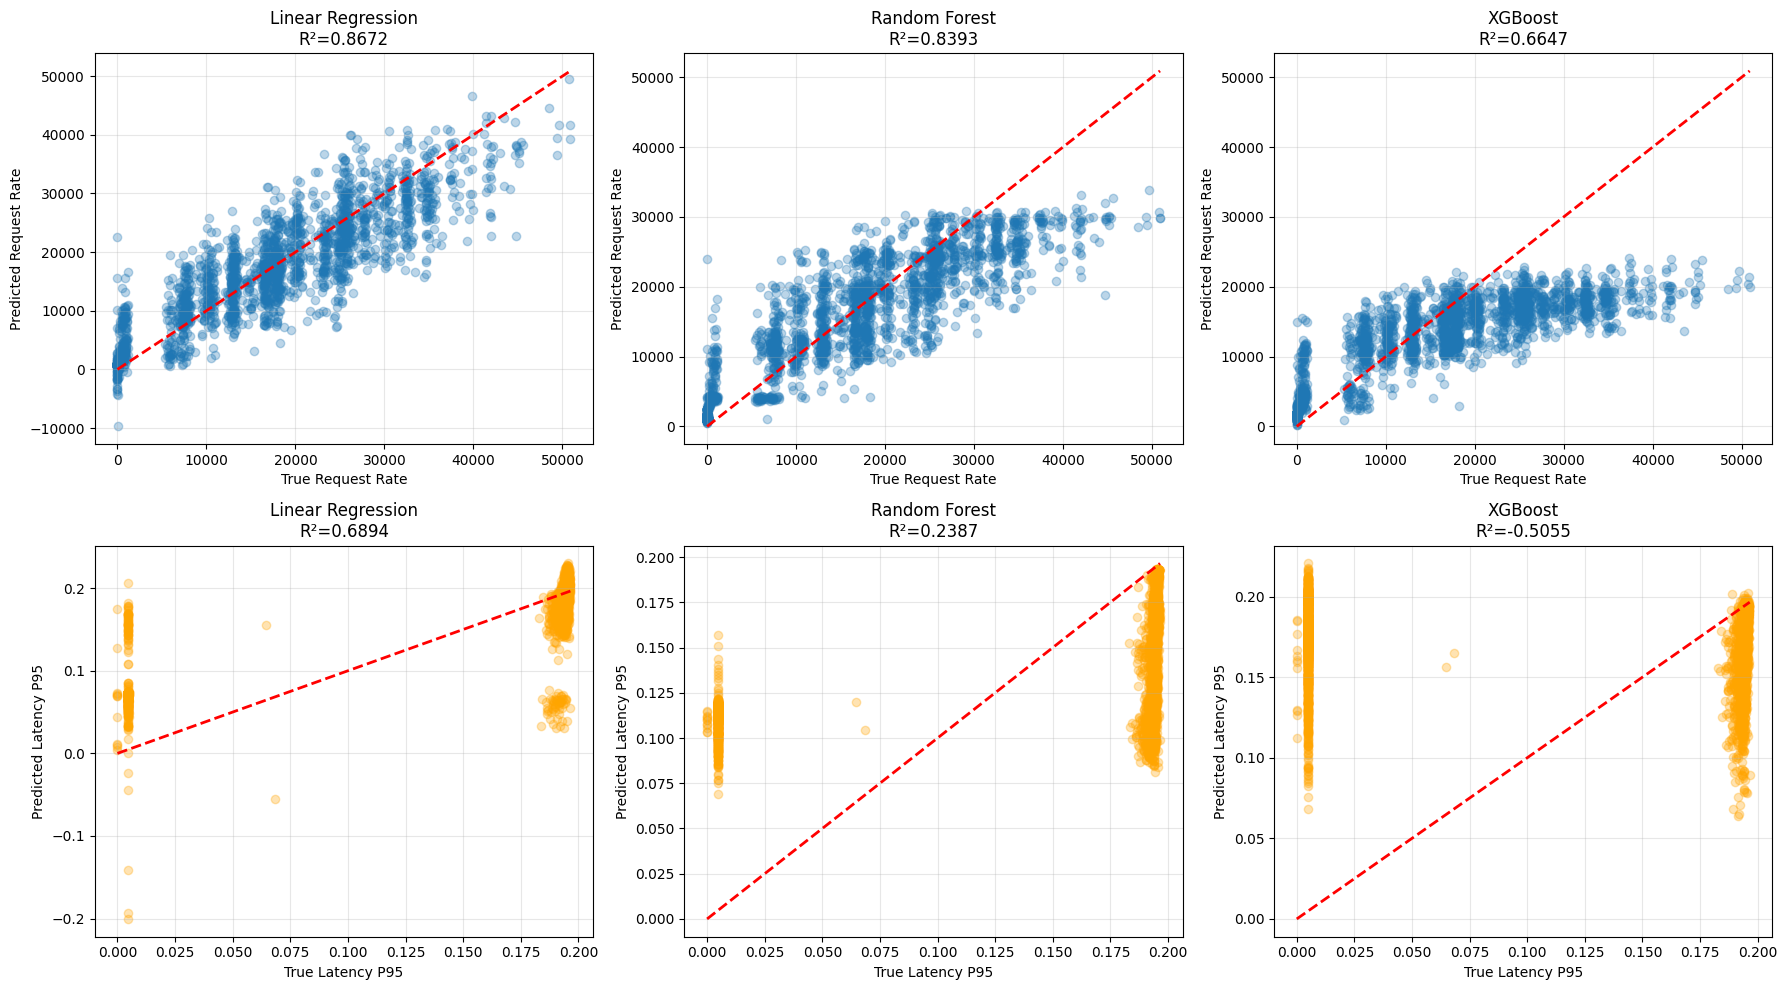

Visualization saved: baseline_predictions.png


In [12]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

models = ['Linear Regression', 'Random Forest', 'XGBoost']
predictions = [lr_test_pred, rf_test_pred, xgb_test_pred]

for i, (model_name, pred) in enumerate(zip(models, predictions)):
    axes[0, i].scatter(y_test[:, 0], pred[:, 0], alpha=0.3)
    axes[0, i].plot([y_test[:, 0].min(), y_test[:, 0].max()], 
                    [y_test[:, 0].min(), y_test[:, 0].max()], 'r--', lw=2)
    axes[0, i].set_xlabel('True Request Rate')
    axes[0, i].set_ylabel('Predicted Request Rate')
    axes[0, i].set_title(f'{model_name}\nR²={r2_score(y_test[:, 0], pred[:, 0]):.4f}')
    axes[0, i].grid(True, alpha=0.3)
    
    axes[1, i].scatter(y_test[:, 1], pred[:, 1], alpha=0.3, color='orange')
    axes[1, i].plot([y_test[:, 1].min(), y_test[:, 1].max()], 
                    [y_test[:, 1].min(), y_test[:, 1].max()], 'r--', lw=2)
    axes[1, i].set_xlabel('True Latency P95')
    axes[1, i].set_ylabel('Predicted Latency P95')
    axes[1, i].set_title(f'{model_name}\nR²={r2_score(y_test[:, 1], pred[:, 1]):.4f}')
    axes[1, i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('baseline_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

print("Visualization saved: baseline_predictions.png")

## Plot time series comparison for a sample window

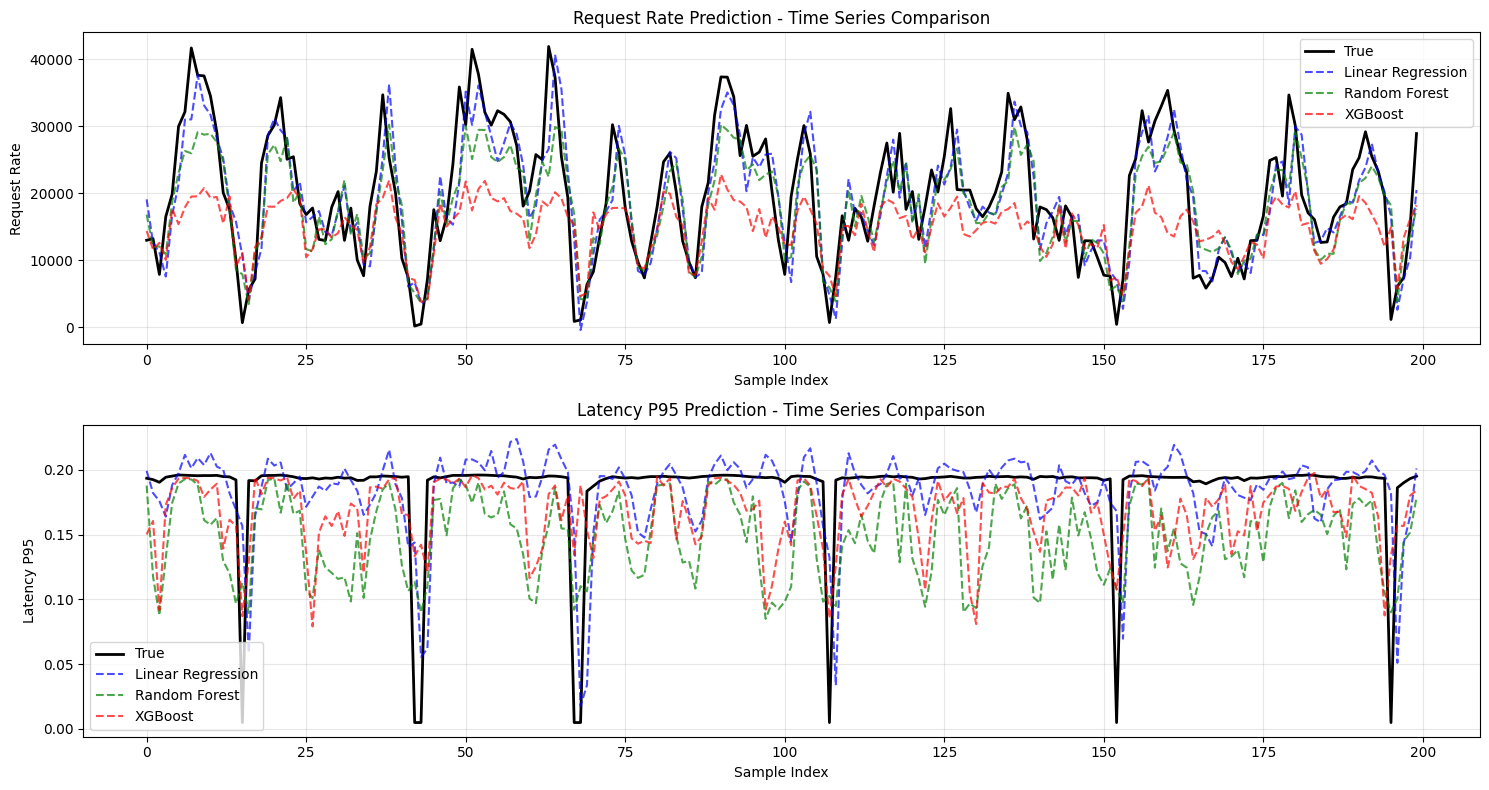

Time series visualization saved: baseline_timeseries.png


In [13]:
sample_size = 200
sample_indices = range(sample_size)

fig, axes = plt.subplots(2, 1, figsize=(15, 8))

axes[0].plot(sample_indices, y_test[:sample_size, 0], 'k-', label='True', linewidth=2)
axes[0].plot(sample_indices, lr_test_pred[:sample_size, 0], 'b--', label='Linear Regression', alpha=0.7)
axes[0].plot(sample_indices, rf_test_pred[:sample_size, 0], 'g--', label='Random Forest', alpha=0.7)
axes[0].plot(sample_indices, xgb_test_pred[:sample_size, 0], 'r--', label='XGBoost', alpha=0.7)
axes[0].set_xlabel('Sample Index')
axes[0].set_ylabel('Request Rate')
axes[0].set_title('Request Rate Prediction - Time Series Comparison')
axes[0].legend(loc='best')
axes[0].grid(True, alpha=0.3)

axes[1].plot(sample_indices, y_test[:sample_size, 1], 'k-', label='True', linewidth=2)
axes[1].plot(sample_indices, lr_test_pred[:sample_size, 1], 'b--', label='Linear Regression', alpha=0.7)
axes[1].plot(sample_indices, rf_test_pred[:sample_size, 1], 'g--', label='Random Forest', alpha=0.7)
axes[1].plot(sample_indices, xgb_test_pred[:sample_size, 1], 'r--', label='XGBoost', alpha=0.7)
axes[1].set_xlabel('Sample Index')
axes[1].set_ylabel('Latency P95')
axes[1].set_title('Latency P95 Prediction - Time Series Comparison')
axes[1].legend(loc='best')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('baseline_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

print("Time series visualization saved: baseline_timeseries.png")

## Save results to CSV files for further analysis

In [14]:
df_results_rr.to_csv('baseline_results_request_rate.csv', index=False)
df_results_lat.to_csv('baseline_results_latency_p95.csv', index=False)

print("Results saved:")
print("  - baseline_results_request_rate.csv")
print("  - baseline_results_latency_p95.csv")

Results saved:
  - baseline_results_request_rate.csv
  - baseline_results_latency_p95.csv


## Save trained models to disk

In [ ]:
import pickle
from pathlib import Path

# Create saved_models directory if it doesn't exist
save_dir = Path('saved_models')
save_dir.mkdir(exist_ok=True)

# Save all three trained models
models_to_save = {
    'linear_regression_model.pkl': lr_model,
    'random_forest_model.pkl': rf_model,
    'xgboost_model.pkl': xgb_model
}

print("Saving trained models...")
for filename, model in models_to_save.items():
    filepath = save_dir / filename
    with open(filepath, 'wb') as f:
        pickle.dump(model, f)
    print(f"  ✓ Saved: {filepath}")

# Also save feature names and model metadata for future reference
model_metadata = {
    'feature_names': feature_cols,
    'target_names': target_cols,
    'train_size': len(X_train),
    'val_size': len(X_val),
    'test_size': len(X_test),
    'best_model_request_rate': df_results_rr.loc[df_results_rr['Test R²'].idxmax(), 'Model'],
    'best_model_latency': df_results_lat.loc[df_results_lat['Test R²'].idxmax(), 'Model']
}

with open(save_dir / 'model_metadata.pkl', 'wb') as f:
    pickle.dump(model_metadata, f)
print(f"  ✓ Saved: {save_dir / 'model_metadata.pkl'}")

print(f"\n✅ All models saved to: {save_dir.absolute()}")
print("Models can be loaded for Stage 7 (External Validation)")

## Summary: Best performing model and key insights

In [15]:
best_model_rr = df_results_rr.loc[df_results_rr['Test R²'].idxmax(), 'Model']
best_r2_rr = df_results_rr['Test R²'].max()
best_mae_rr = df_results_rr.loc[df_results_rr['Test R²'].idxmax(), 'Test MAE']

best_model_lat = df_results_lat.loc[df_results_lat['Test R²'].idxmax(), 'Model']
best_r2_lat = df_results_lat['Test R²'].max()
best_mae_lat = df_results_lat.loc[df_results_lat['Test R²'].idxmax(), 'Test MAE']

best_spike = df_results_rr.loc[df_results_rr['Spike Accuracy'].idxmax(), 'Model']
best_spike_acc = df_results_rr['Spike Accuracy'].max()

print("\n" + "="*60)
print("STAGE 2: BASELINE MODELING - SUMMARY")
print("="*60)
print(f"\nREQUEST RATE PREDICTION:")
print(f"  Best Model: {best_model_rr}")
print(f"  Test R²: {best_r2_rr:.4f}")
print(f"  Test MAE: {best_mae_rr:.2f}")
print(f"\nLATENCY P95 PREDICTION:")
print(f"  Best Model: {best_model_lat}")
print(f"  Test R²: {best_r2_lat:.4f}")
print(f"  Test MAE: {best_mae_lat:.6f}")
print(f"\nSPIKE PREDICTION:")
print(f"  Best Model: {best_spike}")
print(f"  Accuracy: {best_spike_acc:.4f}")
print("\n" + "="*60)
print("All baseline models trained successfully!")
print("Results saved and ready for comparison with Transformer model.")
print("="*60)


STAGE 2: BASELINE MODELING - SUMMARY

REQUEST RATE PREDICTION:
  Best Model: Linear Regression
  Test R²: 0.8672
  Test MAE: 3060.17

LATENCY P95 PREDICTION:
  Best Model: Linear Regression
  Test R²: 0.6894
  Test MAE: 0.039352

SPIKE PREDICTION:
  Best Model: Linear Regression
  Accuracy: 0.9573

All baseline models trained successfully!
Results saved and ready for comparison with Transformer model.
